# 🌍 Air Quality Analysis in India
##  Introduction – 

Air pollution is one of the major environmental challenges affecting cities and communities in India. Air Quality Index (AQI) is an important measure used to understand the overall level of air pollution based on different pollutants.

This project focuses on analyzing air quality across different cities in India using AQI and major pollutants such as PM2.5, PM10, NO, NO₂, NOx, NH₃, CO, SO₂, O₃, Benzene, Toluene, and Xylene. The dataset contains 6,314 records across 9 cities.

The main objective of this project is to explore city-wise pollution patterns, AQI categories, pollutant relationships, and changes in air quality over time using Python and data visualization techniques.

Tools Used:
🐍 Python | 🐼 Pandas | 🔢 NumPy | 📊 Matplotlib | 🎨 Seaborn | 📈 Plotly

## 📋Importing All Required Libraries

In [9]:
import numpy as pn

import pandas as pd 

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

## 📂Load dataset 

In [10]:
df= pd.read_csv("Air Quality Data India.csv")

## 🔎Data Understanding

In [11]:
# Exploration 
df.head()

df.tail()

df.shape

df.columns

df.info()

df.describe()

df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6314 entries, 0 to 6313
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        6314 non-null   object 
 1   Date        6314 non-null   object 
 2   PM2.5       6314 non-null   float64
 3   PM10        6314 non-null   float64
 4   NO          6314 non-null   float64
 5   NO2         6307 non-null   float64
 6   NOx         6243 non-null   float64
 7   NH3         6314 non-null   float64
 8   CO          6314 non-null   float64
 9   SO2         6314 non-null   float64
 10  O3          6314 non-null   float64
 11  Benzene     6314 non-null   float64
 12  Toluene     6314 non-null   float64
 13  Xylene      6314 non-null   float64
 14  AQI         6314 non-null   int64  
 15  AQI_Bucket  6314 non-null   object 
dtypes: float64(12), int64(1), object(3)
memory usage: 789.4+ KB


,City,Date,AQI_Bucket
count,6314,6314,6314
unique,9,1828,6
top,Hyderabad,14-03-2020 0.00,Moderate
freq,1618,9,2557


## 🧹check Missing value 

In [12]:
df.isnull().sum()

City           0
Date           0
PM2.5          0
PM10           0
NO             0
NO2            7
NOx           71
NH3            0
CO             0
SO2            0
O3             0
Benzene        0
Toluene        0
Xylene         0
AQI            0
AQI_Bucket     0
dtype: int64

In [13]:
df["NO2"].fillna(df["NO2"].median(), inplace = True)

In [14]:
df["NOx"].fillna(df["NOx"].median(), inplace = True)

In [15]:
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

## 🔁check duplicated value 

In [6]:
df.duplicated().sum()

np.int64(0)

## 📊shaprate Numarical Coloumn And Categorical Coloumn

In [9]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols, categorical_cols

(Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
        'Benzene', 'Toluene', 'Xylene', 'AQI'],
       dtype='object'),
 Index(['City', 'Date', 'AQI_Bucket'], dtype='object'))

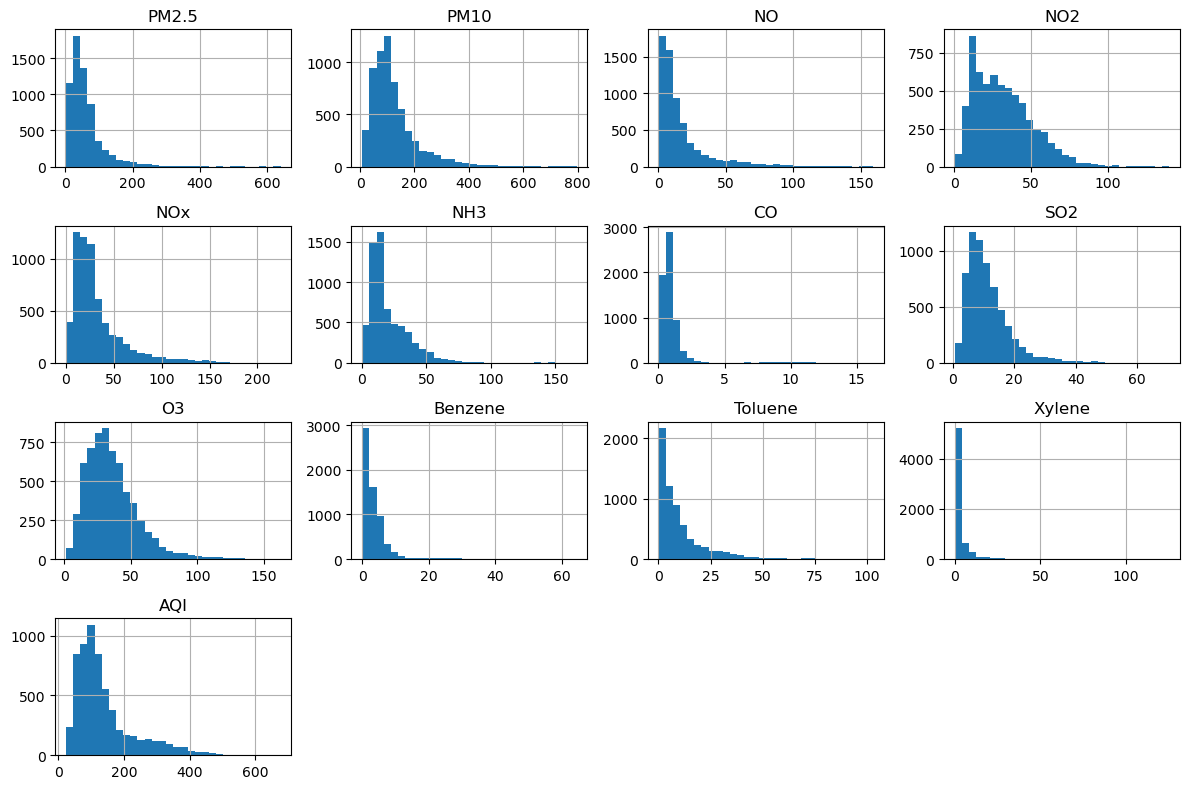

In [10]:
df[numerical_cols].hist(figsize=(12,8),bins=30)
plt.tight_layout()
plt.show()

##  📦 Outlier analysis

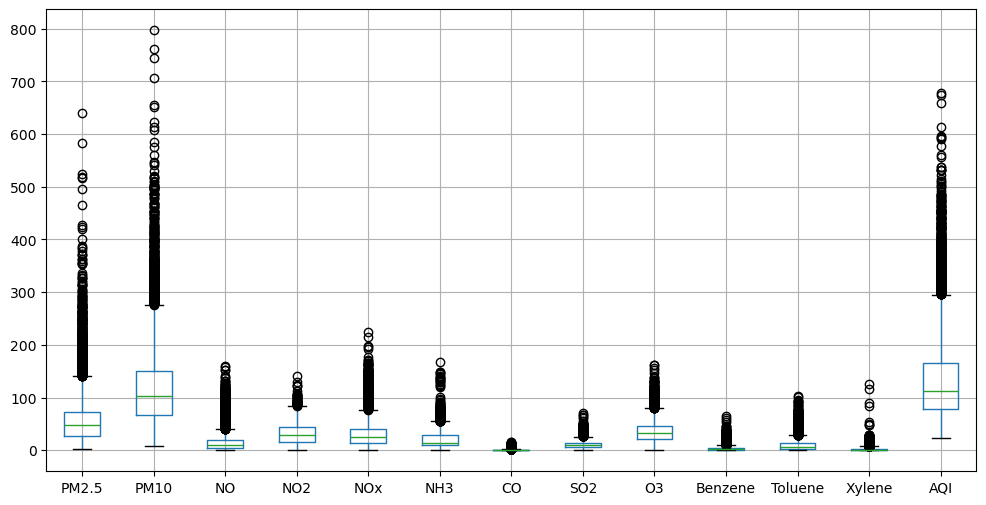

In [8]:
df.boxplot(figsize=(12,6))
plt.show()

In [11]:
print(df.columns.tolist())

['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


## 🏙️ City Distribution


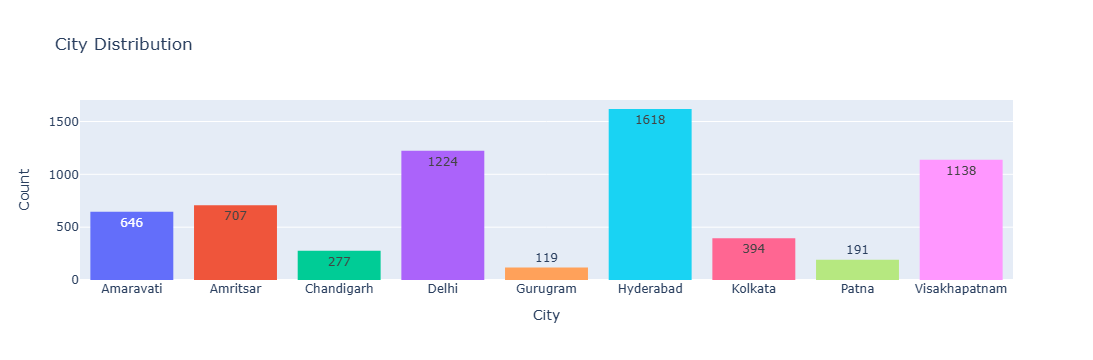

In [12]:
fig = px.histogram(
    df,
    x='City',
    color='City',
    title='City Distribution',
    text_auto=True
)

fig.update_layout(
    xaxis_title='City',
    yaxis_title='Count',
    showlegend=False
)

fig.show()

## insight :

 
The dataset is not evenly distributed across cities, so city-level comparisons should consider the difference in observation counts.


## 📊 AQI Bucket Distribution


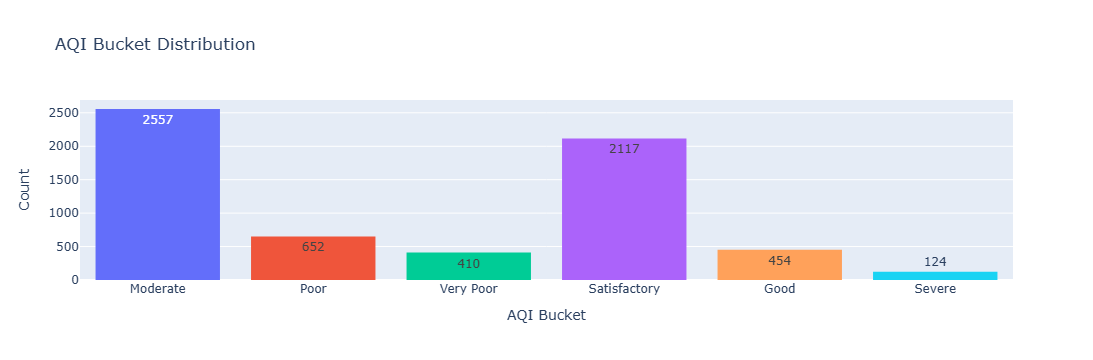

In [13]:
fig = px.histogram(
    df,
    x='AQI_Bucket',
    color='AQI_Bucket',
    title='AQI Bucket Distribution',
    text_auto=True
)

fig.update_layout(
    xaxis_title='AQI Bucket',
    yaxis_title='Count',
    showlegend=False
)

fig.show()

## Insight: 

 A significant portion of the recorded observations represents moderate or satisfactory air-quality conditions.


## 🏙️ AQI Distribution by City


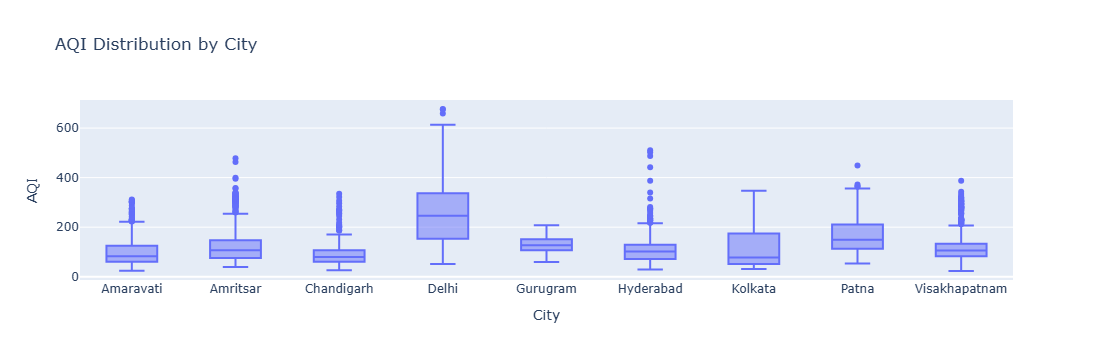

In [18]:
fig = px.box(
    df,
    x='City',
    y='AQI',
    title='AQI Distribution by City'
)

fig.show()

## Insight: 

 Air-quality conditions are not identical across Indian cities in the dataset.

## 📈 Monthly Average AQI Trend


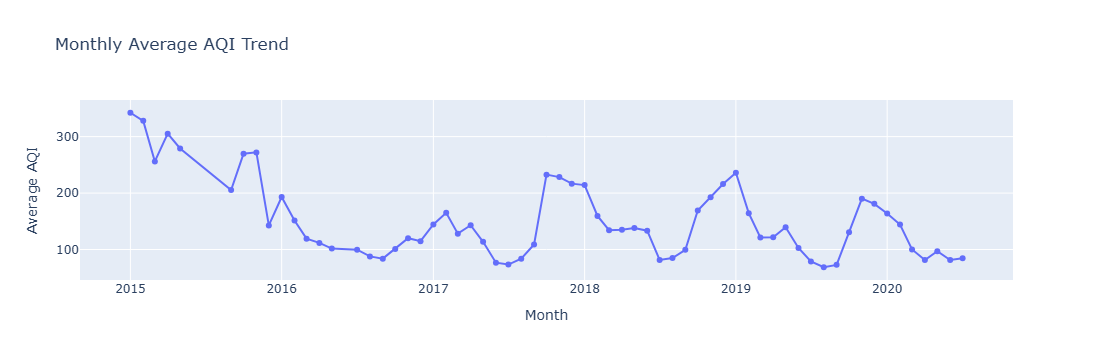

In [17]:
df['Date'] = pd.to_datetime(
    df['Date'],                                                    # Convert Date column
    format='%d-%m-%Y %H.%M'
)

df['Month'] = df['Date'].dt.to_period('M').astype(str)             # Create Month column

monthly_AQI = (
    df.groupby('Month', as_index=False)['AQI']                    # Calculate monthly average AQI
      .mean()
)
fig = px.line(
    monthly_AQI,                                                 # Create line chart
    x='Month',
    y='AQI',
    title='Monthly Average AQI Trend',                        
    markers=True
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Average AQI'
)

fig.show()

## Insight: 

Air quality changes over time rather than remaining constant, indicating the importance of temporal analysis.

## 🔥 Correlation Heatmap


In [10]:
numeric_df = df.select_dtypes(include='number')     # Select numeric columns
corr = numeric_df.corr()                           # Calculate correlation

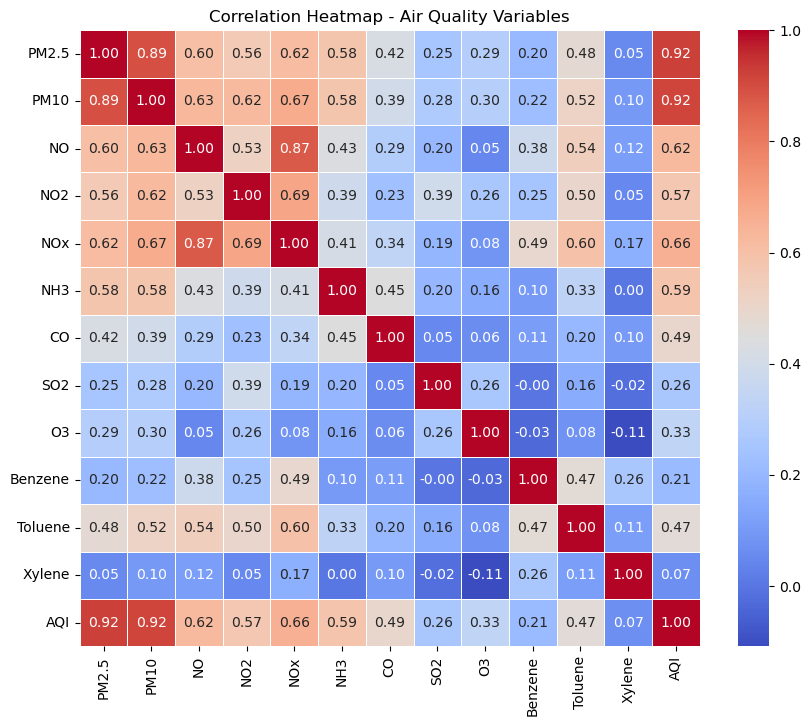

In [17]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap - Air Quality Variables')
plt.show()

In [12]:
aqi_corr = corr['AQI'].drop('AQI').sort_values(ascending=False)

print(aqi_corr)

PM2.5      0.923236
PM10       0.915596
NOx        0.657436
NO         0.619521
NH3        0.588671
NO2        0.574990
CO         0.494772
Toluene    0.466416
O3         0.333478
SO2        0.255686
Benzene    0.208630
Xylene     0.067909
Name: AQI, dtype: float64


## Insight:

 Higher PM2.5 concentrations are strongly associated with higher AQI values in this dataset.

## 🔵 PM2.5 vs AQI


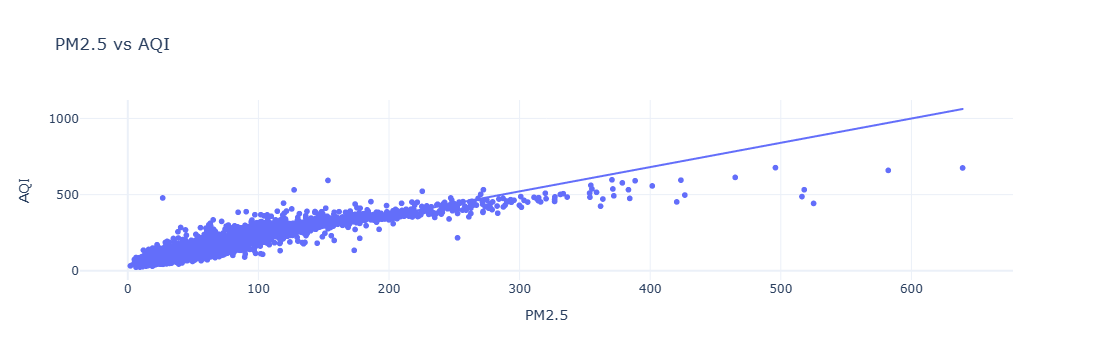

In [13]:
fig = px.scatter(
    df,
    x='PM2.5',
    y='AQI',
    title='PM2.5 vs AQI',
    trendline='ols'
)

fig.update_layout(
    xaxis_title='PM2.5',
    yaxis_title='AQI',
    template='plotly_white'
)

fig.show()

## Insight: 


PM2.5 shows a strong positive association with AQI, indicating that higher PM2.5 concentrations are generally associated with higher AQI values in this dataset.

## 🔵 PM10 vs AQI

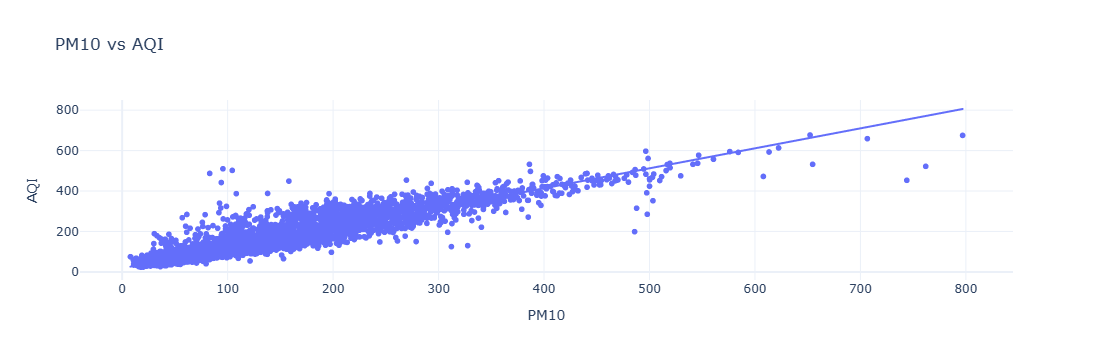

In [14]:
fig = px.scatter(
    df,
    x='PM10',
    y='AQI',
    title='PM10 vs AQI',
    trendline='ols'
)

fig.update_layout(
    xaxis_title='PM10',
    yaxis_title='AQI',
    template='plotly_white'
)

fig.show()

## Insight: 


PM10 also shows a strong positive association with AQI, with the scatter plot showing a clear upward relationship.

## 🏙️ Average AQI by City

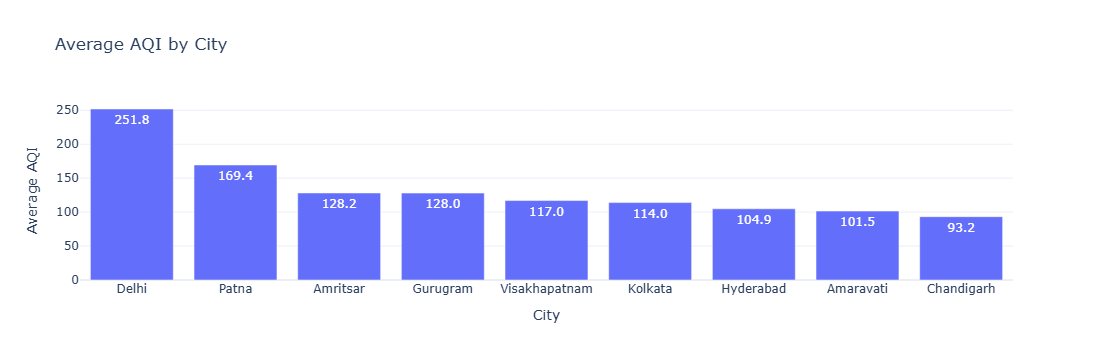

In [15]:
city_avg_aqi = (
    df.groupby('City')['AQI']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    city_avg_aqi,
    x='City',
    y='AQI',
    title='Average AQI by City',
    text_auto='.1f'
)

fig.update_layout(
    xaxis_title='City',
    yaxis_title='Average AQI',
    template='plotly_white'
)

fig.show()

## Insight:

 This allows us to identify cities with relatively higher or lower average AQI and provides a useful city-level comparison.

## 📌KPI summary section

In [17]:
city_avg_aqi = (                                       # Create Average AQI by City
    df.groupby('City')['AQI']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

print("Air Quality Analysis - Key Statistics")         # Key Statistics
print("-" * 45)

print(f"Total Records      : {df.shape[0]}")
print(f"Total Cities       : {df['City'].nunique()}")
print(f"Average AQI        : {df['AQI'].mean():.2f}")
print(f"Maximum AQI        : {df['AQI'].max()}")
print(f"Minimum AQI        : {df['AQI'].min()}")
print(f"Highest AQI City   : {city_avg_aqi.iloc[0]['City']}")
print(f"Lowest AQI City    : {city_avg_aqi.iloc[-1]['City']}")

Air Quality Analysis - Key Statistics
---------------------------------------------
Total Records      : 6314
Total Cities       : 9
Average AQI        : 140.25
Maximum AQI        : 677
Minimum AQI        : 23
Highest AQI City   : Delhi
Lowest AQI City    : Chandigarh


## 🔍 Key Insights

1. The dataset contains 6,314 air-quality observations across multiple Indian cities.

2. Hyderabad has the highest number of observations, while Gurugram has the lowest.

3. Moderate and Satisfactory AQI categories account for the majority of observations.

4. AQI varies considerably across cities, indicating differences in observed air-quality conditions.

5. PM2.5 has the strongest positive correlation with AQI (0.923).

6. PM10 also shows a very strong positive correlation with AQI (0.916).

7. NOx and NO show moderate-to-strong positive relationships with AQI.

8. Xylene has a very weak correlation with AQI (0.068).

9. The PM2.5 vs AQI and PM10 vs AQI scatter plots show clear positive relationships.

10. Monthly analysis shows that AQI changes substantially over the observed time period.

## 🎯Conclusion
The Air Quality Analysis in India project provides an exploratory analysis of AQI and major air pollutants across different cities and over time. 

The analysis reveals significant variation in air quality across cities and months. 

Correlation analysis shows that PM2.5 and PM10 have the strongest positive relationships with AQI, with correlation values of 0.923 and 0.916 respectively.

The scatter plots further support these relationships. Overall, the analysis demonstrates how Python-based data cleaning, exploratory analysis, statistical correlation, and visualization can be used to identify important patterns in air-quality data.